# Image Generation Benchmark — Performance Plots

Visualises results from `data/gtx1070/benchmark_results.json` and `data/p100/benchmark_results.json`.

- **Inference time** — boxplot of 5 timed replicates per (model, mode)
- **Load time** — warm-cache load time (model already on disk) per (model, mode)
- **Peak VRAM** — peak GPU memory per (model, mode)
- **Peak system RAM** — peak host memory per (model, mode)

Missing bars/boxes indicate OOM conditions or (for load time) first-run uncached loads.

In [1]:
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import numpy as np
from pathlib import Path

# ── Load data ──────────────────────────────────────────────────────────────────
data = {hw: json.load(open(Path('data') / hw / 'benchmark_results.json'))
        for hw in ('gtx1070', 'p100')}

# ── Constants ──────────────────────────────────────────────────────────────────
MODEL_ORDER = [
    'sd1_4', 'sd2_1_base', 'sdxl', 'sdxl_turbo',
    'sd3_5_medium', 'sd3_5_large_turbo',
    'kandinsky_2_2', 'pixart_512', 'flux_schnell',
]
MODEL_LABELS = {
    'sd1_4':             'SD 1.4',
    'sd2_1_base':        'SD 2.1',
    'sdxl':              'SDXL',
    'sdxl_turbo':        'SDXL\nTurbo',
    'sd3_5_medium':      'SD 3.5\nMedium',
    'sd3_5_large_turbo': 'SD 3.5\nLg.Turbo',
    'kandinsky_2_2':     'Kandinsky\n2.2',
    'pixart_512':        'PixArt\n512',
    'flux_schnell':      'FLUX.1\nSchnell',
}
MODES = ['gpu_only', 'model_offload', 'sequential_offload']
MODE_LABELS = {
    'gpu_only':           'GPU only',
    'model_offload':      'Model offload',
    'sequential_offload': 'Seq. offload',
}
COLORS = {
    'gpu_only':           '#4C72B0',
    'model_offload':      '#DD8452',
    'sequential_offload': '#55A868',
}
HW_TITLES = {'gtx1070': 'GTX 1070 (8 GB)', 'p100': 'P100 (16 GB)'}

# ── Helpers ────────────────────────────────────────────────────────────────────
def build_table(hw_data, fn):
    """Reshape flat list of entries into {model: {mode: value}}."""
    t = {}
    for e in hw_data:
        t.setdefault(e['model_short'], {})[e['mode']] = fn(e)
    return t

def models_for(hw):
    """Return models present in hw data, in display order."""
    present = {e['model_short'] for e in data[hw]}
    return [m for m in MODEL_ORDER if m in present]

def mode_legend(extra=()):
    handles = [mpatches.Patch(facecolor=COLORS[m], alpha=0.8, label=MODE_LABELS[m])
               for m in MODES]
    return handles + list(extra)

In [2]:
# ── Plotting helpers ───────────────────────────────────────────────────────────
GW = 0.75  # total width of one model's bar/box group

def _style_ax(ax, models, title, ylabel):
    ax.set_xticks(np.arange(len(models)))
    ax.set_xticklabels([MODEL_LABELS[m] for m in models], fontsize=8)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.35, linestyle='--')
    ax.set_ylim(bottom=0)
    ax.set_xlim(-0.5, len(models) - 0.5)
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)

def boxplot_ax(ax, table, models, title, ylabel):
    """Grouped box plots — one box per (model, mode), box from list of values."""
    bw = GW / len(MODES)
    offsets = np.linspace(-GW / 2 + bw / 2, GW / 2 - bw / 2, len(MODES))
    for i, mode in enumerate(MODES):
        bd, pos = [], []
        for j, m in enumerate(models):
            v = table.get(m, {}).get(mode)
            if v:
                bd.append(v)
                pos.append(j + offsets[i])
        if bd:
            ax.boxplot(
                bd, positions=pos, widths=bw * 0.85,
                patch_artist=True,
                boxprops=dict(facecolor=COLORS[mode], alpha=0.8),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color=COLORS[mode]),
                capprops=dict(color=COLORS[mode]),
                flierprops=dict(marker='o', markersize=4,
                               markerfacecolor=COLORS[mode], linestyle='none'),
                manage_ticks=False,
            )
    _style_ax(ax, models, title, ylabel)

def barplot_ax(ax, table, models, title, ylabel):
    """Grouped bar chart — one bar per (model, mode)."""
    bw = GW / len(MODES)
    offsets = np.linspace(-GW / 2 + bw / 2, GW / 2 - bw / 2, len(MODES))
    for i, mode in enumerate(MODES):
        for j, m in enumerate(models):
            v = table.get(m, {}).get(mode)
            if v is not None:
                ax.bar(j + offsets[i], v, width=bw * 0.85,
                       color=COLORS[mode], alpha=0.8)
    _style_ax(ax, models, title, ylabel)

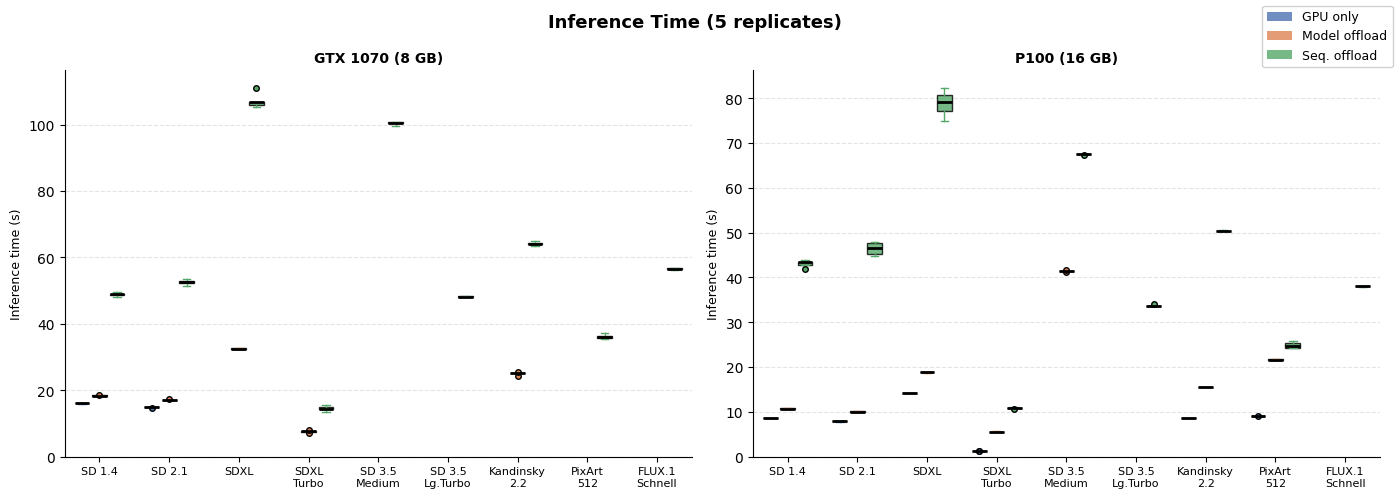

In [3]:
# ── Inference time ─────────────────────────────────────────────────────────────
infer = {
    hw: build_table(data[hw], lambda e: [
        r['elapsed_s'] for r in e['replicates']
        if r['error'] is None and r['elapsed_s'] is not None
    ] or None)
    for hw in data
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, hw in zip(axes, ('gtx1070', 'p100')):
    boxplot_ax(ax, infer[hw], models_for(hw), HW_TITLES[hw], 'Inference time (s)')
fig.suptitle('Inference Time (5 replicates)', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.legend(handles=mode_legend(), loc='upper right', fontsize=9, framealpha=0.9)
plt.show()

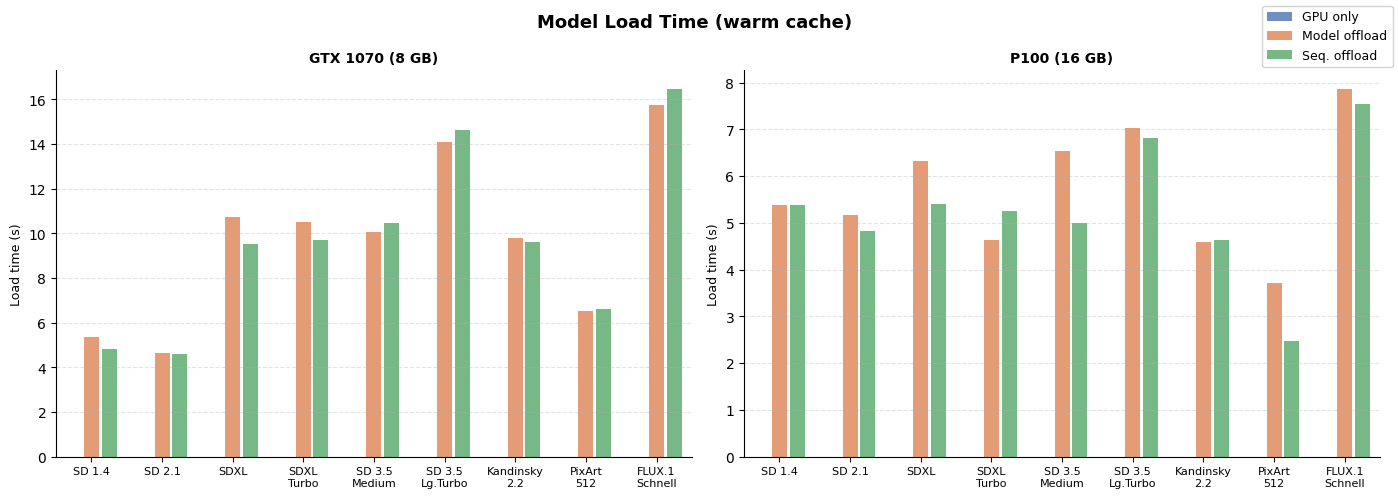

In [4]:
# ── Load time (warm cache only) ────────────────────────────────────────────────
# gpu_only is always the first run for each model (uncached download), so only
# model_offload and sequential_offload entries have cached_at_load=True.
load = {
    hw: build_table(data[hw], lambda e:
        e.get('load_time_s')
        if (not e['load_error'] and e['cached_at_load'])
        else None)
    for hw in data
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, hw in zip(axes, ('gtx1070', 'p100')):
    barplot_ax(ax, load[hw], models_for(hw), HW_TITLES[hw], 'Load time (s)')
fig.suptitle('Model Load Time (warm cache)', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.legend(handles=mode_legend(), loc='upper right', fontsize=9, framealpha=0.9)
plt.show()

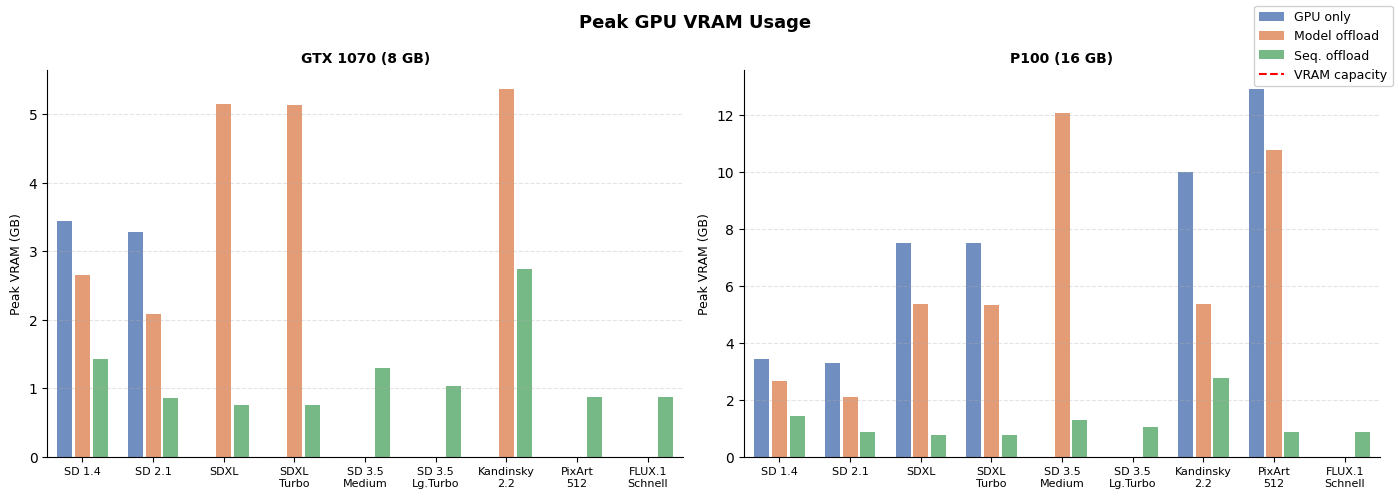

In [5]:
# ── Peak GPU VRAM ──────────────────────────────────────────────────────────────
vram = {
    hw: build_table(data[hw], lambda e:
        e['peak_gpu_vram_mb'] / 1024
        if e.get('peak_gpu_vram_mb') is not None else None)
    for hw in data
}
VRAM_CAP = {'gtx1070': 8.0, 'p100': 16.0}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, hw in zip(axes, ('gtx1070', 'p100')):
    barplot_ax(ax, vram[hw], models_for(hw), HW_TITLES[hw], 'Peak VRAM (GB)')
    ax.axhline(VRAM_CAP[hw], color='red', linestyle='--', linewidth=1.2, alpha=0.8)
fig.suptitle('Peak GPU VRAM Usage', fontsize=13, fontweight='bold')
plt.tight_layout()
cap_line = Line2D([0], [0], color='red', linestyle='--', linewidth=1.5, label='VRAM capacity')
fig.legend(handles=mode_legend(extra=[cap_line]), loc='upper right', fontsize=9, framealpha=0.9)
plt.show()

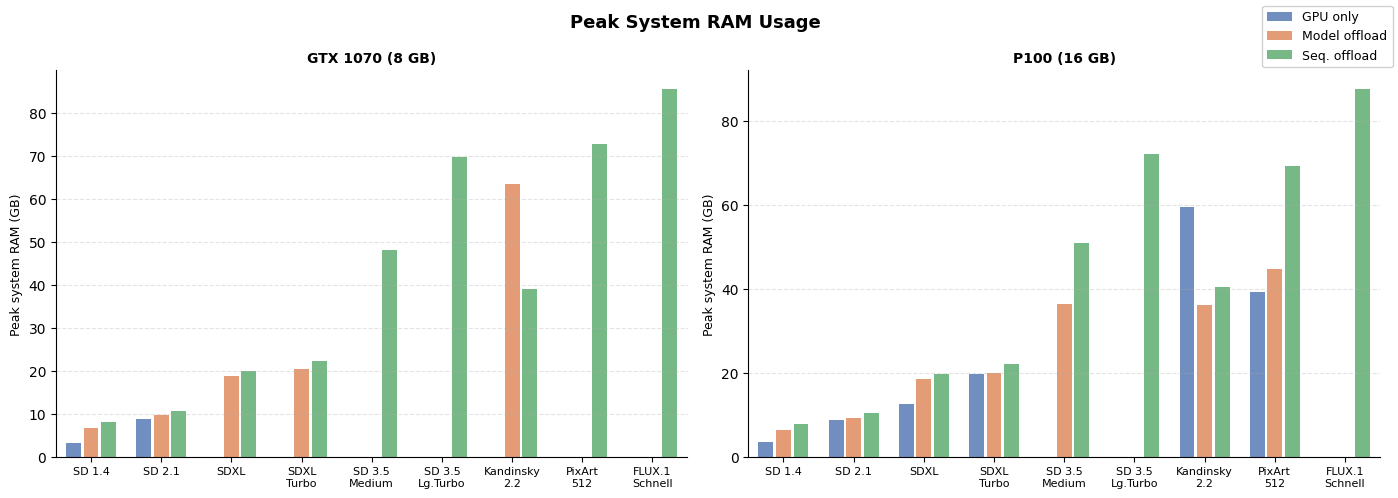

In [6]:
# ── Peak system RAM ────────────────────────────────────────────────────────────
ram = {
    hw: build_table(data[hw], lambda e:
        e['peak_system_ram_mb'] / 1024
        if e.get('peak_system_ram_mb') is not None else None)
    for hw in data
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, hw in zip(axes, ('gtx1070', 'p100')):
    barplot_ax(ax, ram[hw], models_for(hw), HW_TITLES[hw], 'Peak system RAM (GB)')
fig.suptitle('Peak System RAM Usage', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.legend(handles=mode_legend(), loc='upper right', fontsize=9, framealpha=0.9)
plt.show()